In [2]:
# 1. Importação das bibliotecas essenciais
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Para o nosso Boxplot avançado

# 2. Carregamento dos dados exportados do SQL
df1 = pd.read_csv('/content/drive/MyDrive/SCTEC_DATAVIZ&BI/Proj-Aval-Mod1/query_01.csv')
df2 = pd.read_csv('/content/drive/MyDrive/SCTEC_DATAVIZ&BI/Proj-Aval-Mod1/query_02.csv')

# 3. Análise Exploratória de Dados (EDA)
print("--- RAIO-X DO DF1 (Cargos e Departamentos) ---")
df1.info()
print("\nValores Nulos no DF1:")
display(df1.isnull().sum())

print("\n" + "="*50 + "\n")

print("--- RAIO-X DO DF2 (Distribuição Geográfica) ---")
df2.info()
print("\nValores Nulos no DF2:")
display(df2.isnull().sum())

# 4. Estatística Descritiva dos Salários (Comprovando os dados do README)
print("\n--- ESTATÍSTICA DESCRITIVA (Salários Globais) ---")

# Calculando a média e a mediana exatas
media_global = df1['SALARY'].mean()
mediana_global = df1['SALARY'].median()

print(f"Média Global: $ {media_global:.2f}")
print(f"Mediana Global: $ {mediana_global:.2f}")

# Resumo estatístico completo
print("\nResumo Estatístico Completo da coluna de Salários:")
display(df1[['SALARY']].describe())


--- RAIO-X DO DF1 (Cargos e Departamentos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   FIRST_NAME       107 non-null    object
 1   LAST_NAME        107 non-null    object
 2   SALARY           107 non-null    int64 
 3   DEPARTMENT_NAME  106 non-null    object
 4   JOB_TITLE        107 non-null    object
dtypes: int64(1), object(4)
memory usage: 4.3+ KB

Valores Nulos no DF1:


,0
FIRST_NAME,0
LAST_NAME,0
SALARY,0
DEPARTMENT_NAME,1
JOB_TITLE,0




--- RAIO-X DO DF2 (Distribuição Geográfica) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106 entries, 0 to 105
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   FIRST_NAME      106 non-null    object
 1   LAST_NAME       106 non-null    object
 2   SALARY          106 non-null    int64 
 3   CITY            106 non-null    object
 4   STATE_PROVINCE  105 non-null    object
 5   COUNTRY_NAME    106 non-null    object
 6   REGION_NAME     106 non-null    object
dtypes: int64(1), object(6)
memory usage: 5.9+ KB

Valores Nulos no DF2:


,0
FIRST_NAME,0
LAST_NAME,0
SALARY,0
CITY,0
STATE_PROVINCE,1
COUNTRY_NAME,0
REGION_NAME,0



--- ESTATÍSTICA DESCRITIVA (Salários Globais) ---
Média Global: $ 6461.83
Mediana Global: $ 6200.00

Resumo Estatístico Completo da coluna de Salários:


,SALARY
count,107.000000
mean,6461.831776
std,3909.579731
min,2100.000000
25%,3100.000000
50%,6200.000000
75%,8900.000000
max,24000.000000


--- TABELA: Salários por Departamento e Cargo ---


,Departamento,Cargo,Qtd_Funcionarios,Media_Salarial
4,Executive,President,1,24000.000000
3,Executive,Administration Vice President,2,17000.000000
9,Marketing,Marketing Manager,1,13000.000000
14,Sales,Sales Manager,5,12200.000000
6,Finance,Finance Manager,1,12008.000000
0,Accounting,Accounting Manager,1,12008.000000
13,Purchasing,Purchasing Manager,1,11000.000000
11,Public Relations,Public Relations Representative,1,10000.000000
15,Sales,Sales Representative,29,8396.551724
1,Accounting,Public Accountant,1,8300.000000


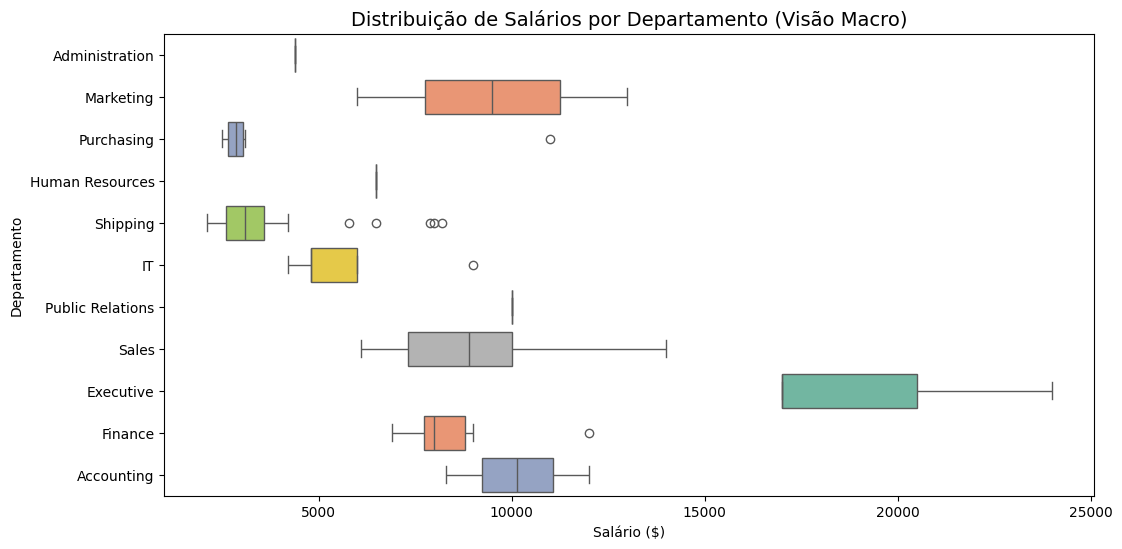


--- TABELA: Distribuição Geográfica de Salários ---


,País,Qtd_Funcionarios,Media_Salarial
3,United States of America,68,5064.941176
2,United Kingdom of Great Britain and Northern I...,35,8885.714286
0,Canada,2,9500.000000
1,Germany,1,10000.000000


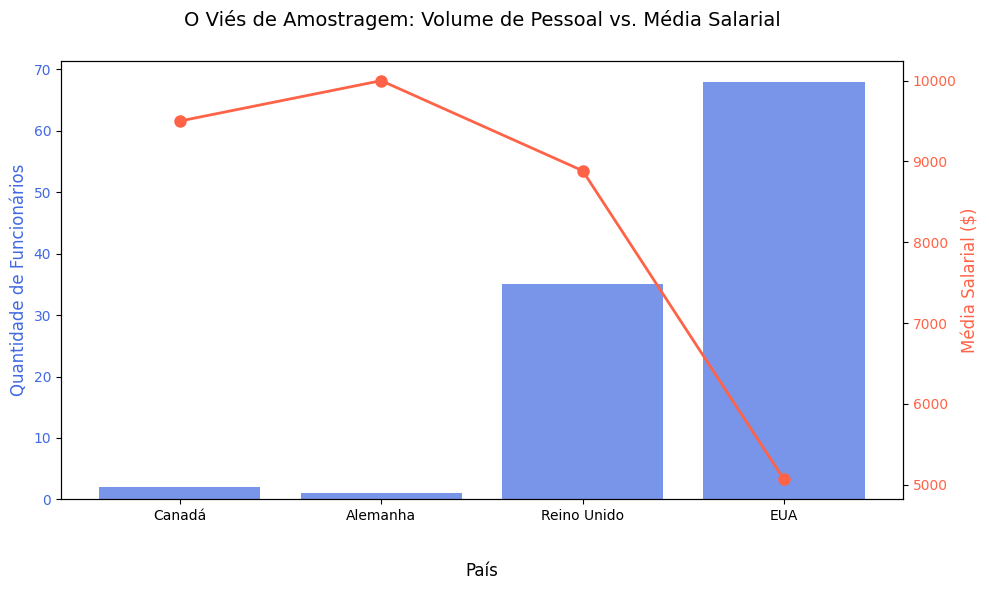

In [3]:
# --- QUERY 1: SALÁRIOS POR DEPARTAMENTO E CARGO ---
print("--- TABELA: Salários por Departamento e Cargo ---")

analise_q1 = df1.groupby(
    ['DEPARTMENT_NAME', 'JOB_TITLE']
)['SALARY'].agg(['count', 'mean']).reset_index()

analise_q1.columns = [
    'Departamento',
    'Cargo',
    'Qtd_Funcionarios',
    'Media_Salarial'
]

display(
    analise_q1.sort_values(
        by='Media_Salarial',
        ascending=False
    )
)


# --- GRÁFICO DA QUERY 1: BOXPLOT ---
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df1,
    x='SALARY',
    y='DEPARTMENT_NAME',
    hue='DEPARTMENT_NAME',
    palette='Set2',
    legend=False
)

plt.title(
    'Distribuição de Salários por Departamento (Visão Macro)',
    fontsize=14
)

plt.xlabel('Salário ($)')
plt.ylabel('Departamento')

plt.show()


# --- QUERY 2: DISTRIBUIÇÃO GEOGRÁFICA E O VIÉS DE AMOSTRAGEM ---
print("\n--- TABELA: Distribuição Geográfica de Salários ---")

distribuicao_pais = df2.groupby(
    'COUNTRY_NAME'
)['SALARY'].agg(['count', 'mean']).reset_index()

distribuicao_pais.columns = [
    'País',
    'Qtd_Funcionarios',
    'Media_Salarial'
]

display(
    distribuicao_pais.sort_values(
        by='Qtd_Funcionarios',
        ascending=False
    )
)


# --- ABREVIAÇÃO DOS NOMES DOS PAÍSES PARA O GRÁFICO ---
abreviacoes_paises = {
    'Canada': 'Canadá',
    'Germany': 'Alemanha',
    'United Kingdom of Great Britain and Northern Ireland': 'Reino Unido',
    'United States of America': 'EUA'
}

distribuicao_pais['País_Abrev'] = distribuicao_pais[
    'País'
].map(abreviacoes_paises)


# --- GRÁFICO DA QUERY 2: COMBO CHART AVANÇADO ---
fig, ax1 = plt.subplots(figsize=(10, 6))


# Eixo esquerdo — Barras: Volume de Pessoas
cor_barras = 'royalblue'

ax1.bar(
    distribuicao_pais['País_Abrev'],
    distribuicao_pais['Qtd_Funcionarios'],
    color=cor_barras,
    alpha=0.7
)

# Rótulo inferior com maior distância do eixo X
ax1.set_xlabel(
    'País',
    fontsize=12,
    labelpad=28
)

ax1.set_ylabel(
    'Quantidade de Funcionários',
    color=cor_barras,
    fontsize=12
)

ax1.tick_params(
    axis='y',
    labelcolor=cor_barras
)


# Eixo direito — Linha: Média Salarial
ax2 = ax1.twinx()

cor_linha = 'tomato'

ax2.plot(
    distribuicao_pais['País_Abrev'],
    distribuicao_pais['Media_Salarial'],
    color=cor_linha,
    marker='o',
    linewidth=2,
    markersize=8
)

ax2.set_ylabel(
    'Média Salarial ($)',
    color=cor_linha,
    fontsize=12
)

ax2.tick_params(
    axis='y',
    labelcolor=cor_linha
)


# --- AJUSTES FINAIS DO GRÁFICO ---
plt.title(
    'O Viés de Amostragem: Volume de Pessoal vs. Média Salarial',
    fontsize=14,
    pad=25
)

# Países no eixo horizontal e rótulo inferior
plt.xticks(
    rotation=0,
    ha='center'
)

plt.tight_layout()

plt.show()

--- TABELA: Disparidade Salarial no Mesmo Cargo ---


,Cargo,min,max,count,Disparidade_Salarial
6,Programmer,4200,9000,5,4800
12,Stock Manager,5800,8200,5,2400
0,Accountant,6900,9000,5,2100
10,Shipping Clerk,2500,4200,20,1700
11,Stock Clerk,2100,3600,20,1500
8,Purchasing Clerk,2500,3100,5,600
3,Administration Vice President,17000,17000,2,0


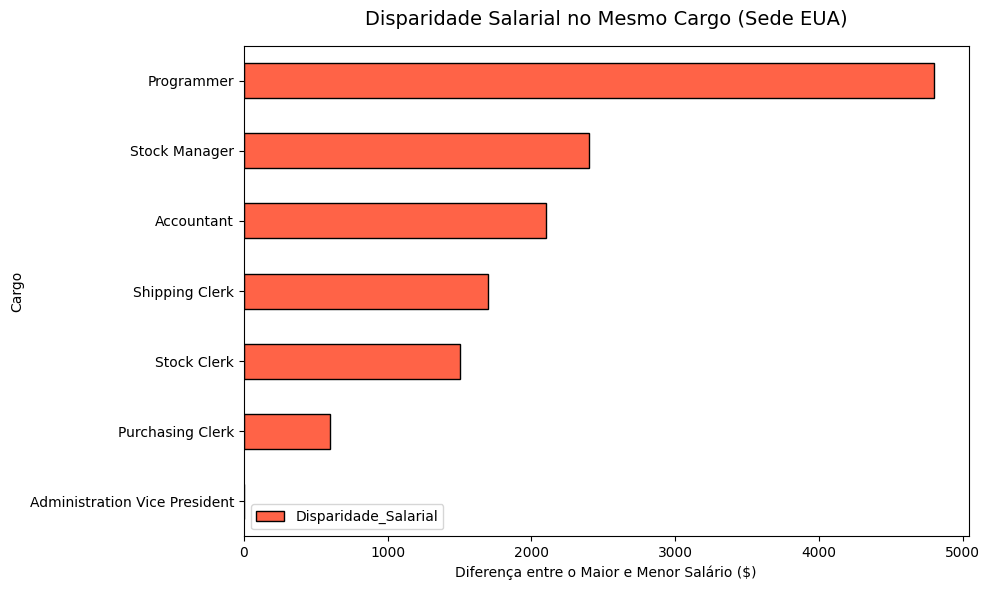

In [ ]:
# --- O ZOOM INVESTIGATIVO: EQUIDADE SALARIAL NOS EUA ---

# 1. Cruzamento dos dados limpos
df_completo = pd.merge(df1, df2, on=['FIRST_NAME', 'LAST_NAME'])

# 2. Filtrando apenas os EUA
df_eua = df_completo[df_completo['COUNTRY_NAME'] == 'United States of America']

# 3. Calculando estatísticas por cargo nos EUA
job_salary_stats_eua = df_eua.groupby('JOB_TITLE')['SALARY_x'].agg(['min', 'max', 'count']).reset_index()

# 4. Filtrando cargos com mais de 1 pessoa e calculando a disparidade
cargos_comparaveis = job_salary_stats_eua[job_salary_stats_eua['count'] > 1].copy()
cargos_comparaveis['Disparidade_Salarial'] = cargos_comparaveis['max'] - cargos_comparaveis['min']
cargos_comparaveis.rename(columns={'JOB_TITLE': 'Cargo'}, inplace=True)

print("--- TABELA: Disparidade Salarial no Mesmo Cargo ---")
display(cargos_comparaveis.sort_values(by='Disparidade_Salarial', ascending=False))

# 5. Gráfico Final: A verdade sobre a equidade
grafico_micro = cargos_comparaveis.sort_values(by='Disparidade_Salarial', ascending=True)
grafico_micro.plot(x='Cargo', y='Disparidade_Salarial', kind='barh', figsize=(10, 6), color='tomato', edgecolor='black')
plt.title('Disparidade Salarial no Mesmo Cargo (Sede EUA)', fontsize=14, pad=15)
plt.xlabel('Diferença entre o Maior e Menor Salário ($)')
plt.ylabel('Cargo')
plt.tight_layout()
plt.show()